In [1]:
import sys
sys.path.insert(0, ".")
from src.frame_extractor import FrameExtractor, ExtractionConfig
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

objc[45019]: Class AVFFrameReceiver is implemented in both /Users/jasmineguan/miniforge3/envs/video_caption/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x103a703a8) and /Users/jasmineguan/miniforge3/envs/video_caption/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10d8043a8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[45019]: Class AVFAudioReceiver is implemented in both /Users/jasmineguan/miniforge3/envs/video_caption/lib/python3.12/site-packages/av/.dylibs/libavdevice.62.1.100.dylib (0x103a703f8) and /Users/jasmineguan/miniforge3/envs/video_caption/lib/python3.12/site-packages/cv2/.dylibs/libavdevice.61.3.100.dylib (0x10d8043f8). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.


In [5]:
config = ExtractionConfig(
    frames_per_segment=10,
    output_format="jpg",
    output_dir="output/frames",
)
extractor = FrameExtractor(config)

results = extractor.extract_from_video(
    video_path="tests/sample_videos/sample.mp4",
    video_id="smoke_test",
    timestamps=[[0, 4.0], [10.0, 20.0]],
    sentences=["First segment.", "Second segment."],
)

for seg in results:
    print(f"Segment {seg.segment_index}: [{seg.timestamp_start:.1f}s → {seg.timestamp_end:.1f}s]")
    print(f"  Frames saved: {len(seg.frame_paths)}")

Segment 0: [0.0s → 4.0s]
  Frames saved: 10
Segment 1: [10.0s → 20.0s]
  Frames saved: 10


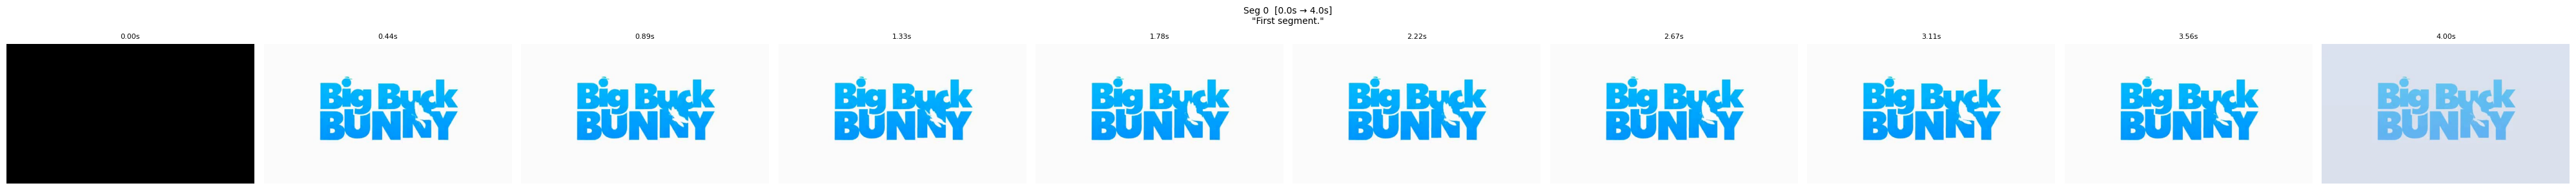

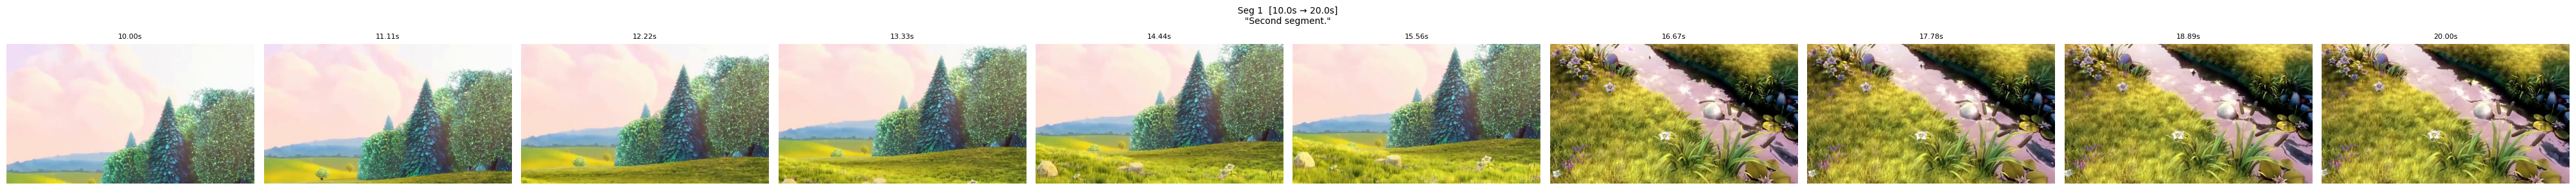

In [6]:
for seg in results:
    n = len(seg.frame_paths)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 3))
    fig.suptitle(
        f'Seg {seg.segment_index}  [{seg.timestamp_start:.1f}s → {seg.timestamp_end:.1f}s]\n"{seg.sentence}"',
        fontsize=10
    )
    for ax, path, ft in zip(axes, seg.frame_paths, seg.frame_timestamps):
        ax.imshow(mpimg.imread(path))
        ax.set_title(f"{ft:.2f}s", fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    plt.show()